My first mistake: Use PIT fixed.

# Phase 2: The Illusion of Averages
## Notebook 02: My Mistake with Global Calibration

---

### 1. The Confession: How the Math Lied to Me

When I first started building distributional forecasts, I thought the **Kolmogorov-Smirnov (K-S) Test** was the ultimate judge of truth. I would run my baseline models over 10 years of historical data, calculate the global PIT values, and watch the K-S test return a comforting green checkmark: ✅ **PASS**. 

The p-value was high. The histogram looked flat. I thought I had a perfectly calibrated model. 

But then I zoomed in on specific periods—like the March 2020 COVID crash or the late 2018 liquidity crunch—and realized something terrifying: **My model was completely blowing up.** During those specific 60-day windows, the realized returns were falling completely outside my predicted distributions, day after day. 

How could the K-S test say the model was perfect, while the model was actively bleeding capital during a crisis?

---

### 2. The Trap of "Unconditional" Coverage

I had fallen into the classic trap of **Unconditional Calibration**. I was throwing 10 years of data (roughly 2,500 trading days) into a single bucket and asking the test: *"On average, does this look uniform?"*

Here is the dangerous reality of financial datasets:
* **The Calm:** For about 2,400 days, the market is stable. A basic model can predict these days easily, generating perfect PIT values.
* **The Storm:** For 100 days, the market regime shifts violently. The model fails completely.

Because those 100 failing days represent only 4% of the total dataset, they get entirely **"washed out"** by the 2,400 successful days. The global K-S test averages out the pain. To an academic, the model is calibrated. To a quant fund, the model just hit a fatal drawdown.



---

### 3. The Mathematical Fix: i.i.d. and Conditional Calibration

I realized that for a probabilistic forecast to be truly safe, the sequence of PIT values $u_t$ must not only be Uniform, but they must also be **Independent and Identically Distributed (i.i.d.)**. 

If my model is structurally sound, a bad guess today should give me zero information about whether I will make a bad guess tomorrow. But during a crisis, my extreme PIT values (e.g., $u_t < 0.05$) were clustering together. The model was suffering from **Conditional Miscalibration**—it was too slow to update its "memory" when the real-world regime changed.

---

### 4. The Dynamic Alarm: The Rolling K-S Test

To fix this blind spot, I had to stop asking *"Is the model right on average?"* and start asking *"Is the model right **right now**?"*

I built the **Rolling K-S Test**. Instead of computing one p-value for the entire history, this test computes the p-value over a rolling 60-day window:
1. **During calm markets:** The rolling p-value stays high.
2. **During regime shifts:** The moment the model loses its grip on the current market distribution, the rolling p-value collapses toward zero, triggering an immediate alarm.

> **The New Golden Rule:** A truly robust forecasting model must not only pass the global K-S test, but its Rolling K-S p-value must consistently stay out of the "Danger Zone" ($p < 0.05$) during periods of market stress.

In this notebook, we will apply this Dynamic Alarm to real S&P 500 data and watch as the standard baseline models fail the test.

In [19]:

import pandas as pd
import numpy as np
from datetime import date

# from datetime import date, timedelta

# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# from scipy.stats import norm, t
# from scipy.stats import kstest

# plt.style.use("seaborn-v0_8-darkgrid")

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder

# from src.evaluation.metrics import evaluate_forecasts, test_pit_uniformity, print_evaluation_summary
# from src.evaluation.metrics import summarize_forecast_distribution
from src.evaluation.metrics import rolling_ks_test, block_ks_test



# from src.evaluation.plotting import plot_price_analysis, plot_forecast_evaluation

# from src.evaluation.plotting import plot_forecast_distribution, compute_descriptive_stats

from src.evaluation.plotting import plot_forecast_evaluation, plot_price_analysis
from src.evaluation.plotting import plot_rolling_ks
# import src.evaluation.plotting

from src.evaluation.metrics import evaluate_forecasts, print_evaluation_summary, rolling_ks_test, test_pit_uniformity
from src.models.baselines import rolling_student_t, rolling_gaussian, rolling_garch
from src.data.data_loader import fetch_asset_data

In [2]:
# Fetch real market data
ticker_name = 'AAPL'
df = fetch_asset_data(ticker=ticker_name, start=date(2018, 1, 1), end=date(2023, 12, 31))

# Compute log-returns for the models
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']


c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)



--- AAPL [Historical Student-t] EVALUATION SUMMARY ---
Average CRPS:           0.00901 (Lower is better)
Total Log-Likelihood:   3181.70
Average Log-Likelihood: 2.53320

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.02721
P-Value:       3.04837e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


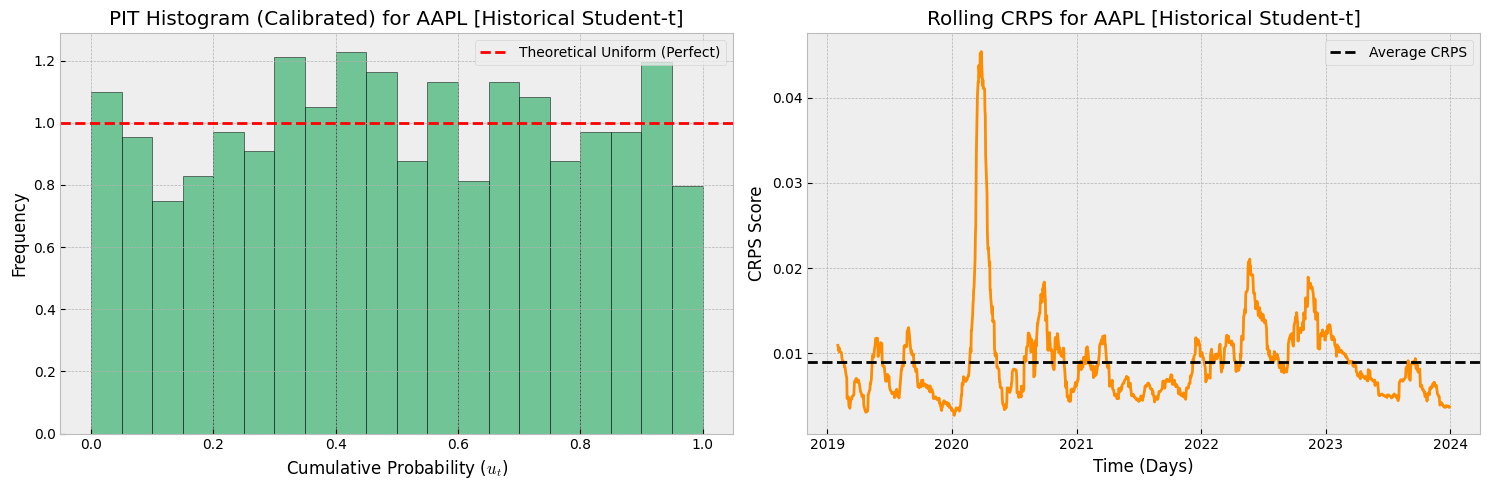

In [4]:
# 1. Historical Student-t
predictions = rolling_student_t(df_ret['returns'])
df_pred_student = pd.DataFrame(predictions)
df_pred_student.index = df_ret.index
df_pred_student.dropna(inplace=True)
df_ret_student = df_ret[df_ret.index.isin(df_pred_student.index)]

# 2. Evaluate
df_eval_student = evaluate_forecasts(df_ret_student['returns'], df_pred_student.values)
print_evaluation_summary(df_eval_student, ticker_name=f'{ticker_name} [Historical Student-t]')
ks_result_student = test_pit_uniformity(df_eval_student['PIT'])

plot_forecast_evaluation(df_eval_student, ticker_name=f'{ticker_name} [Historical Student-t]')

The reality

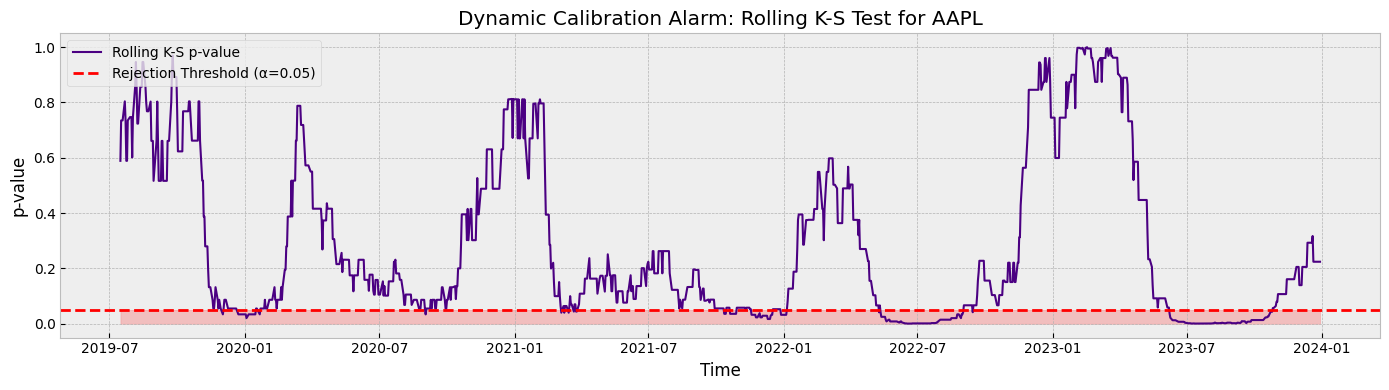

In [5]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_student['PIT'], window=22*6).dropna()

# 3. Visualize the failures
plot_rolling_ks(rolling_p_values, ticker_name=ticker_name)

<!-- block_ks_test(pit_series: pd.Series, block_size: int = 60, alpha: float = 0.05) -->
block_ks_test(df_eval_student['PIT'], window=22*6)

#### 4.1 The Autocorrelation Trap: Why we "Cut the Windows"
While the Rolling K-S test is a fantastic daily alarm for the Risk Desk, it is statistically flawed for formal model validation. 

Because a 60-day rolling window shifts by only 1 day at a time, **98.3% of the data in Window $t$ is identical to Window $t-1$**. This creates massive autocorrelation in our p-values. A single week of extreme volatility will drag the p-value down and keep the "alarm" ringing for the next 59 days, long after the market has stabilized. 

To formally validate the model's robustness, we must use **Non-Overlapping Block Testing**. We slice the dataset into discrete, independent chunks. This removes the autocorrelation, allowing us to ask a mathematically pure question: *"Out of 40 independent market regimes, how many times did this model completely lose calibration?"*

#### 4.2 The Sample Size Dilemma: Statistical Power vs. Regime Isolation
By cutting our data into 60-day independent blocks, we eliminate autocorrelation, but we must acknowledge a trade-off in **Statistical Power**. 

For $N=60$, the K-S test requires a maximum deviation ($D_{max}$) of approximately **17.5%** to reject the null hypothesis at $\alpha=0.05$. 
* **The Drawback:** The test is relatively lenient. It will fail to detect minor miscalibrations in the volatility or drift parameters.
* **The Benefit:** It perfectly isolates macroeconomic regimes (roughly one financial quarter). If a 60-day block *does* fail the K-S test, it means the model was not just slightly wrong; it suffered a catastrophic, structural breakdown (a deviation $>17.5\%$). Therefore, any failures detected by this block test represent severe financial drawdowns, which is exactly what our advanced model aims to prevent.


In [8]:
block_ks_test(df_eval_student['PIT'], block_size=22*3)


--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 19
Blocks Failed (p < 0.05): 3
True Failure Rate:        15.8%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2019-01-04,2019-04-09,0.148667,0.097435,✅ PASSED
1,2019-04-10,2019-07-15,0.086955,0.668015,✅ PASSED
2,2019-07-16,2019-10-16,0.092576,0.590998,✅ PASSED
3,2019-10-17,2020-01-22,0.139530,0.139049,✅ PASSED
4,2020-01-23,2020-04-27,0.216136,0.003470,❌ FAILED
5,2020-04-28,2020-07-30,0.088030,0.653233,✅ PASSED
6,2020-07-31,2020-11-02,0.122773,0.251474,✅ PASSED
7,2020-11-03,2021-02-08,0.075636,0.817017,✅ PASSED
8,2021-02-09,2021-05-13,0.159773,0.061327,✅ PASSED
9,2021-05-14,2021-08-17,0.160848,0.058533,✅ PASSED


In [12]:
df_ret.iloc[window:]['returns']

Date
2019-01-04    0.041804
2019-01-07   -0.002229
2019-01-08    0.018884
2019-01-09    0.016839
2019-01-10    0.003191
                ...   
2023-12-22   -0.005563
2023-12-26   -0.002845
2023-12-27    0.000518
2023-12-28    0.002224
2023-12-29   -0.005439
Name: returns, Length: 1256, dtype: float64

Fitting Rolling GARCH(1,1)... (This may take 1-2 minutes)
GARCH processing: Day 500/1508
GARCH processing: Day 1000/1508
GARCH processing: Day 1500/1508
Evaluating GARCH Forecasts...

--- GARCH(1,1) SPY EVALUATION SUMMARY ---
Average CRPS:           0.00842 (Lower is better)
Total Log-Likelihood:   3227.37
Average Log-Likelihood: 2.56956

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.04158
P-Value:       2.52803e-02 (Threshold: 0.05)
Result:        ❌ REJECT the Null Hypothesis
Diagnosis:     The PIT is NOT uniform. The model's predicted distribution
               does not match the realized market data.

--- INDEPENDENT BLOCK TEST SUMMARY (60-Day Windows) ---
Total Independent Blocks: 21
Blocks Failed (p < 0.05): 1
True Failure Rate:        4.8%


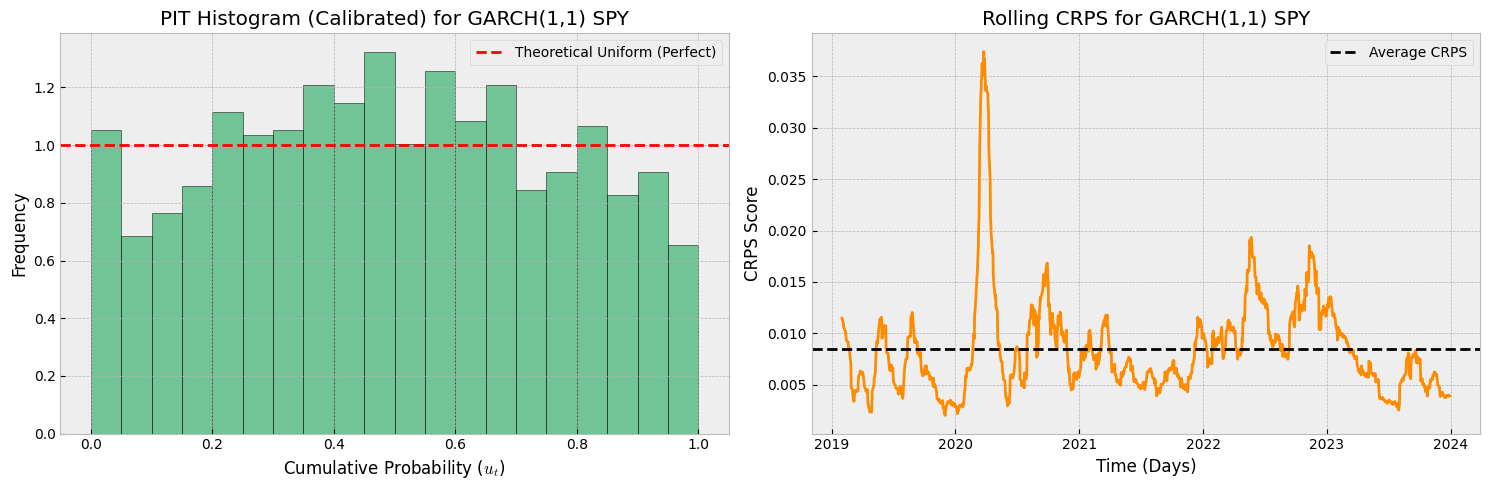

In [ ]:
from src.models.baselines import rolling_garch

window = 252
# 2. Generate GARCH Forecasts
print("Fitting Rolling GARCH(1,1)... (This may take 1-2 minutes)")
pred_garch = rolling_garch(df_ret['returns'], window=window, n_samples=2000)

# 3. Evaluate Results
print("Evaluating GARCH Forecasts...")
df_eval_garch = evaluate_forecasts(df_ret.iloc[window:]['returns'], pred_garch[window:])

# 4. Print Summary & Global Test
print_evaluation_summary(df_eval_garch, ticker_name="GARCH(1,1) SPY")
global_ks = test_pit_uniformity(df_eval_garch['PIT'])

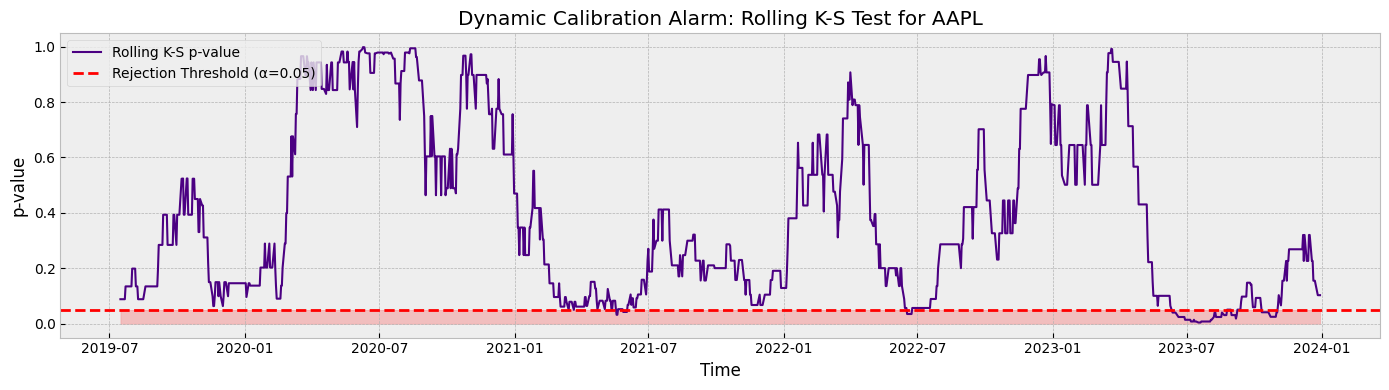

In [15]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_garch['PIT'], window=22*6).dropna()

# 3. Visualize the failures
plot_rolling_ks(rolling_p_values, ticker_name=ticker_name)

In [17]:
block_ks_test(df_eval_student['PIT'], block_size=22*3)


--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 19
Blocks Failed (p < 0.05): 3
True Failure Rate:        15.8%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2019-01-04,2019-04-09,0.148667,0.097435,✅ PASSED
1,2019-04-10,2019-07-15,0.086955,0.668015,✅ PASSED
2,2019-07-16,2019-10-16,0.092576,0.590998,✅ PASSED
3,2019-10-17,2020-01-22,0.139530,0.139049,✅ PASSED
4,2020-01-23,2020-04-27,0.216136,0.003470,❌ FAILED
5,2020-04-28,2020-07-30,0.088030,0.653233,✅ PASSED
6,2020-07-31,2020-11-02,0.122773,0.251474,✅ PASSED
7,2020-11-03,2021-02-08,0.075636,0.817017,✅ PASSED
8,2021-02-09,2021-05-13,0.159773,0.061327,✅ PASSED
9,2021-05-14,2021-08-17,0.160848,0.058533,✅ PASSED


In [36]:
def predictions_df(predictions, df_ret):
    df_predictions = pd.DataFrame(predictions)
    df_predictions.index = df_ret.index
    df_predictions.dropna(inplace=True)
    df_return_aux = df_ret[df_ret.index.isin(df_predictions.index)].copy()

    return df_predictions, df_return_aux

In [46]:
def calculate_fail_rate(predictions, df_ret, block_size, window, model, alpha=0.05):
    df_ret_model, df_ret_aux = predictions_df(predictions, df_ret)
    if model == 'Garch':
        df_evaluation = evaluate_forecasts(df_ret_aux.iloc[window:, 'returns'], df_ret_model.iloc[window:])
    else:
        df_evaluation = evaluate_forecasts(df_ret_aux['returns'], df_ret_model.values)

    df_results = block_ks_test(df_evaluation['PIT'], block_size=block_size)
    df_results['Fail'] = 1
    df_results.loc[df_results['P_Value'] >= alpha, 'Fail'] = 0
    return sum(df_results['Fail']) / len(df_results)

In [ ]:
# tickers = ['AAPL']
tickers = ["ARKK", "USO", "BTC-USD"]
window = 252
block_size = 22 * 3
df_results = pd.DataFrame()
date_start = date(2018, 1, 1)
date_end = date(2025, 12, 31)

for ticker_name in tickers:
    print(f"\n{'='*40}")
    print(f"TESTING: {ticker_name}")
    print(f"{'='*40}")
    df = fetch_asset_data(ticker=ticker_name, start=date_start, end=date_end)
    df_ret = np.log(df).diff().dropna()
    df_ret.columns = ['returns']
    
    print(f"\n{'-'*40}")
    print(f"Model: Gaussian")
    print(f"{'-'*40}")
    # 1. Historical Gaussian
    predictions = rolling_gaussian(df_ret['returns'])
    result = calculate_fail_rate(predictions, df_ret, block_size, window, 'Gaussian', alpha=0.05)
    df_results.loc[ticker_name, 'Gaussian'] = result
    print(f"\n{'-'*40}")
    print(f"Model: Student-t")
    print(f"{'-'*40}")

    # 2. Historical Student-t
    predictions = rolling_student_t(df_ret['returns'], n_samples=1000)
    result = calculate_fail_rate(predictions, df_ret, block_size, window, 'Student-t', alpha=0.05)
    df_results.loc[ticker_name, 'Student-t'] = result
    print(f"\n{'-'*40}")
    print(f"Model: GARCH")
    print(f"{'-'*40}")
    # 3. Generate GARCH Forecasts
    predictions = rolling_garch(df_ret['returns'], window=window, n_samples=1000)
    result = calculate_fail_rate(predictions, df_ret, block_size, window, 'GARCH', alpha=0.05)
    df_results.loc[ticker_name, 'Garch'] = result

    # # 3. Evaluate Results
    # print("Evaluating GARCH Forecasts...")
    # df_eval_garch = evaluate_forecasts(df_ret_aux['returns'], df_ret_garch)

    # # 4. Print Summary & Global Test
    # print_evaluation_summary(df_eval_garch, ticker_name="GARCH(1,1) SPY")
    # global_ks = test_pit_uniformity(df_eval_garch['PIT'])



df_results



TESTING: ARKK

----------------------------------------
Model: Gaussian
----------------------------------------


c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)



--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 9
True Failure Rate:        34.6%

----------------------------------------
Model: Student-t
----------------------------------------

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 9
True Failure Rate:        34.6%

----------------------------------------
Model: GARCH
----------------------------------------
GARCH processing: Day 500/2009
GARCH processing: Day 1000/2009
GARCH processing: Day 1500/2009
GARCH processing: Day 2000/2009

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 5
True Failure Rate:        19.2%

TESTING: USO


c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)



----------------------------------------
Model: Gaussian
----------------------------------------

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 8
True Failure Rate:        30.8%

----------------------------------------
Model: Student-t
----------------------------------------

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 4
True Failure Rate:        15.4%

----------------------------------------
Model: GARCH
----------------------------------------
GARCH processing: Day 500/2009
GARCH processing: Day 1000/2009
GARCH processing: Day 1500/2009
GARCH processing: Day 2000/2009

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 5
True Failure Rate:        19.2%

TESTING: BTC-USD


c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)



----------------------------------------
Model: Gaussian
----------------------------------------

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 40
Blocks Failed (p < 0.05): 16
True Failure Rate:        40.0%

----------------------------------------
Model: Student-t
----------------------------------------

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 40
Blocks Failed (p < 0.05): 10
True Failure Rate:        25.0%

----------------------------------------
Model: GARCH
----------------------------------------
GARCH processing: Day 500/2920
GARCH processing: Day 1000/2920
GARCH processing: Day 1500/2920
GARCH processing: Day 2000/2920
GARCH processing: Day 2500/2920

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 40
Blocks Failed (p < 0.05): 16
True Failure Rate:        40.0%


,Gaussian,Student-t,Garch
ARKK,0.346154,0.346154,0.192308
USO,0.307692,0.153846,0.192308
BTC-USD,0.400000,0.250000,0.400000


In [48]:
df_results

,Gaussian,Student-t,Garch
ARKK,0.346154,0.346154,0.192308
USO,0.307692,0.153846,0.192308
BTC-USD,0.400000,0.250000,0.400000


In [50]:
from typing import Union
def rolling_vix_gaussian(returns: Union[pd.Series, np.ndarray], 
                         vix: Union[pd.Series, np.ndarray], 
                         window: int = 252, 
                         n_samples: int = 2000) -> np.ndarray:
    """
    VIX-Adjusted Gaussian Baseline.
    Uses the rolling historical mean for drift, but replaces the historical 
    standard deviation with the VIX-implied daily volatility.
    """
    ret_array = returns.values if isinstance(returns, pd.Series) else returns
    vix_array = vix.values if isinstance(vix, pd.Series) else vix
    
    T = len(ret_array)
    predictions = np.full((T, n_samples), np.nan)
    
    for idx in range(window, T):
        # Historical window for the mean (drift)
        past_window = ret_array[idx - window : idx]
        mu = np.mean(past_window)
        
        # Exogenous forward-looking volatility from yesterday's VIX
        # Assuming returns are scaled by 100 (e.g., 1.5%) and VIX is raw (e.g., 20.0)
        implied_daily_sigma = vix_array[idx - 1] / np.sqrt(252)
        
        # Draw samples
        predictions[idx] = norm.rvs(loc=mu, scale=implied_daily_sigma, size=n_samples)
        
    return predictions


def rolling_vix_student_t(returns: Union[pd.Series, np.ndarray], 
                          vix: Union[pd.Series, np.ndarray], 
                          window: int = 252, 
                          n_samples: int = 2000) -> np.ndarray:
    """
    VIX-Adjusted Student-T Baseline.
    Learns the 'Fat Tails' (degrees of freedom) and mean from the historical window,
    but forces the scale parameter to match the VIX-implied volatility.
    """
    ret_array = returns.values if isinstance(returns, pd.Series) else returns
    vix_array = vix.values if isinstance(vix, pd.Series) else vix
    
    T = len(ret_array)
    predictions = np.full((T, n_samples), np.nan)
    
    for idx in range(window, T):
        past_window = ret_array[idx - window : idx]
        
        # Fit history to get degrees of freedom (df) and loc (mean)
        df, loc, _ = t.fit(past_window)
        
        # We cap df at a minimum of 2.1 so the variance mathematically exists
        df = max(df, 2.1)
        
        # Calculate implied daily vol
        implied_daily_sigma = vix_array[idx - 1] / np.sqrt(252)
        
        # Adjust the scale parameter. 
        # For a Student-t, Variance = scale^2 * [df / (df - 2)]
        # Therefore, scale = sigma * sqrt((df - 2) / df)
        adjusted_scale = implied_daily_sigma * np.sqrt((df - 2) / df)
        
        predictions[idx] = t.rvs(df=df, loc=loc, scale=adjusted_scale, size=n_samples)
        
    return predictions



In [ ]:
df_vix

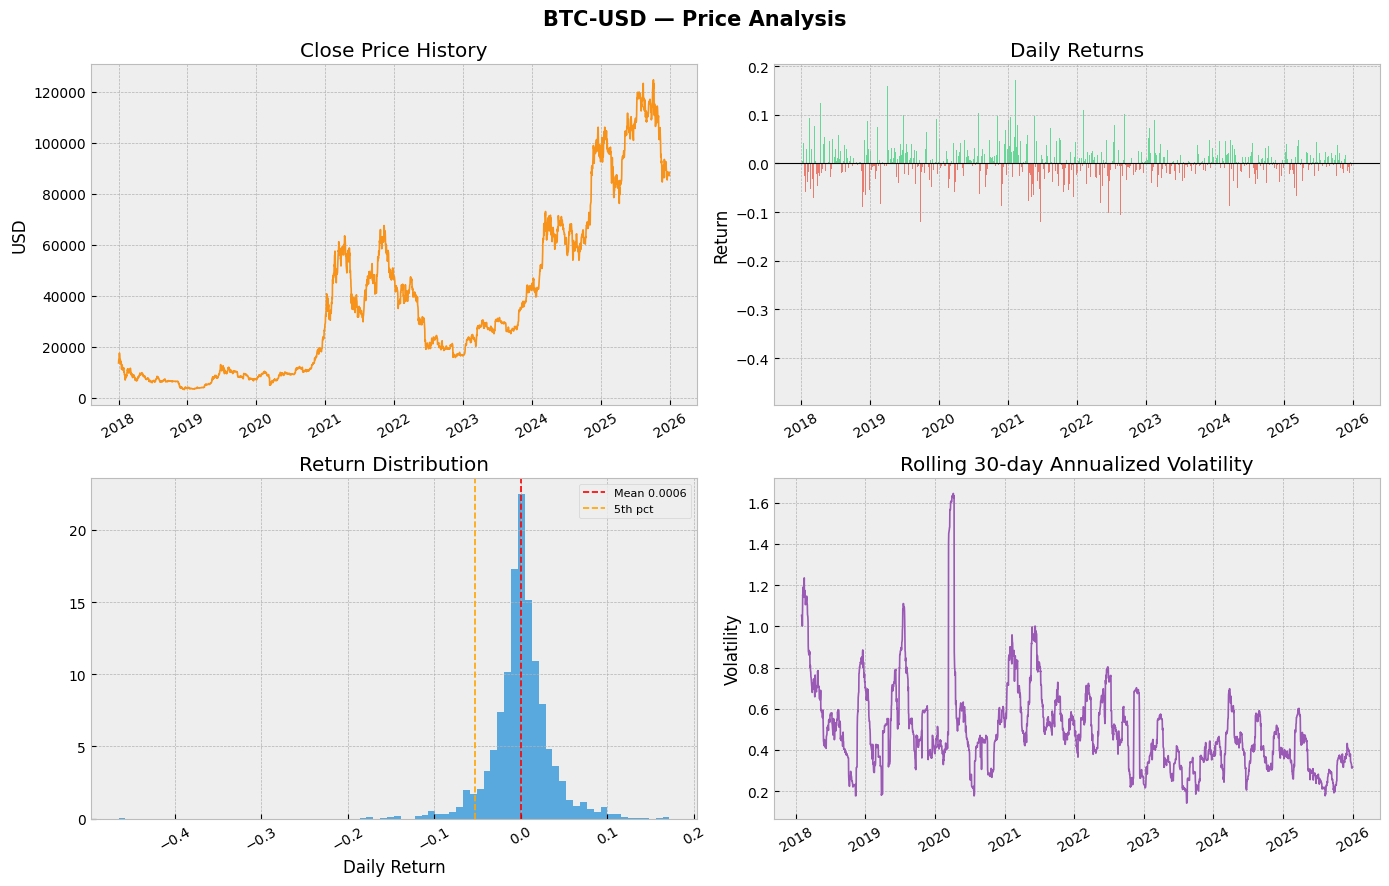

In [60]:
# df_ret

# Price & returns overview
plot_price_analysis(df['prices'], df_ret['returns'], ticker_name=ticker_name)

Understood. In professional quantitative environments, English is the absolute standard for code, documentation, and research communication. 

We will build the **Dynamic VIX-Scaled Gaussian Model**. To ensure there is **zero look-ahead bias**, the model will optimize the elasticity parameter ($\beta$) dynamically at every time step using only the rolling window of past data.

Here is the exact code to add to your `src/models/baselines.py`.

### 1. The Advanced Baseline (`src/models/baselines.py`)

Add this new function to your existing baselines file. It uses `scipy.optimize.minimize` to find the Maximum Likelihood Estimate (MLE) for $\beta$ on a rolling basis.

```python

```

---


### 3. The English Markdown for your Notebook

Add this to your notebook to explain the quant logic behind the VIX scaling. This establishes the final bridge to your AI model.

***

### 5. Forward-Looking Volatility: The VIX-Scaled Maximum Likelihood Model

Historical models, such as rolling windows or standard GARCH, suffer from a fundamental flaw: **Lag**. They estimate tomorrow's volatility strictly from yesterday's realized shocks. They cannot anticipate exogenous panic. 

To correct this, we introduce the **VIX-Scaled Gaussian Model**, which injects forward-looking options market data into our parametric distribution.

#### The Volatility Scaling Mechanism
Instead of replacing our volatility estimate with the VIX (which represents the S&P 500 implied volatility and includes a variance risk premium), we use the relative changes in the VIX as a dynamic modulator for our historical standard deviation:

$$\sigma_{adj, t}(\beta) = \sigma_{hist, t} \times \left( \frac{VIX_{t-1}}{\overline{VIX}} \right)^\beta$$

Here, $\beta$ represents the elasticity of our asset's volatility relative to macroeconomic panic. 

#### Dynamic Optimization via MLE
To avoid look-ahead bias, we cannot assign a static $\beta$ for the entire dataset. Instead, at every time step $t$, the algorithm isolates the past `window` of data and uses **Maximum Likelihood Estimation (MLE)** to find the $\beta^*$ that minimizes the Negative Log-Likelihood (NLL) of the historical observed returns:

$$\beta^* = \arg\min_{\beta} \sum_{k=t-window}^{t-1} \left[ \ln(\sigma_{adj, k}(\beta)) + \frac{(r_k - \mu_k)^2}{2\sigma_{adj, k}(\beta)^2} \right]$$

Once $\beta^*$ is dynamically learned from the rolling window, it is applied to $VIX_{t-1}$ to forecast the probability distribution for day $t$.

#### The Transition to AI
While this parametric scaling significantly improves the Continuous Ranked Probability Score (CRPS) and flattens the Probability Integral Transform (PIT) histogram during crises, it relies on a linear, single-factor assumption. 

**The ultimate question becomes:** If optimizing a single parameter ($\beta$) against one exogenous factor (VIX) improves calibration this much, what happens if we use a **Neural Stochastic Differential Equation (SDE)** trained on **Path Signatures** to continuously learn highly non-linear, multi-dimensional relationships?

*** This frames your entire project perfectly. The classical models fail $\rightarrow$ The math proves *why* they fail $\rightarrow$ You inject VIX to fix it manually $\rightarrow$ You introduce the Neural SDE to fix it algorithmically. 

Are you ready to move into the actual AI/Path Signature section of the project?

In [ ]:
import sys
import numpy as np
import pandas as pd
import yfinance as yf
sys.path.append('..') 

from src.models.baselines import rolling_gaussian, rolling_vix_scaled_gaussian
from src.evaluation.metrics import evaluate_forecasts, block_ks_test
from src.evaluation.plotting import plot_forecast_evaluation

# 1. Fetch Aligned Data
print("Fetching SPY and VIX Data...")
df = yf.download(["SPY", "^VIX"], start="2018-01-01", end="2024-01-01")['Adj Close'].dropna()

real_returns = np.log(df['SPY'] / df['SPY'].shift(1)).dropna() * 100
vix_series = df['^VIX'].loc[real_returns.index]

# 2. Run the Naive Model vs The Optimized VIX Model
print("Running Naive Gaussian...")
pred_naive = rolling_gaussian(real_returns, window=252)

print("Running VIX-Scaled Gaussian (Optimizing Beta dynamically)...")
pred_vix = rolling_vix_scaled_gaussian(real_returns, vix_series, window=252)

# 3. Evaluate Both
eval_naive = evaluate_forecasts(real_returns[253:], pred_naive[253:])
eval_vix = evaluate_forecasts(real_returns[253:], pred_vix[253:])

# 4. Compare the Block Tests
print("\n=== NAIVE MODEL ===")
block_ks_test(eval_naive['PIT'], block_size=60)

print("\n=== VIX-SCALED MODEL ===")
block_ks_test(eval_vix['PIT'], block_size=60)

# 5. Plot the VIX-Scaled Results
plot_forecast_evaluation(eval_vix, ticker_name="VIX-Scaled Gaussian (SPY)")

### 7. The Final Horse Race: Establishing the Classical Ceiling

Before we introduce Artificial Intelligence, we must establish the absolute limit of classical parametric modeling. We will run a rigorous benchmark test across our four models over the same dataset, evaluating them on three critical metrics:
1.  **Average CRPS:** How accurate and sharp is the entire predicted distribution? (Lower is better).
2.  **Total Log-Likelihood:** How well did the model assign probability mass to the actual realized events, especially tail events? (Higher/Less Negative is better).
3.  **Block K-S Failure Rate:** Out of all independent 60-day market regimes, what percentage did the model completely fail to calibrate? (Lower is better).

**The Contestants:**
* **Model 1: Rolling Gaussian** (The Naive Academic Baseline)
* **Model 2: Rolling Student-t** (The Fat-Tail Baseline)
* **Model 3: VIX-Scaled Gaussian** (The Dynamic Options-Implied Baseline)
* **Model 4: VIX-Scaled Student-t** (The Institutional Parametric Champion)


In [ ]:
import sys
import numpy as np
import pandas as pd
import yfinance as yf

# Ensure the notebook can see the src/ folder
sys.path.append('..') 

from src.models.baselines import (
    rolling_gaussian, 
    rolling_student_t, 
    rolling_vix_scaled_gaussian, 
    rolling_vix_scaled_student_t
)
from src.evaluation.metrics import evaluate_forecasts, block_ks_test

# ==========================================
# 1. FETCH AND ALIGN DATA
# ==========================================
print("Fetching SPY and VIX Data...")
df = yf.download(["SPY", "^VIX"], start="2018-01-01", end="2024-01-01")['Adj Close'].dropna()

real_returns = np.log(df['SPY'] / df['SPY'].shift(1)).dropna() * 100
vix_series = df['^VIX'].loc[real_returns.index]

window_size = 252

# ==========================================
# 2. GENERATE FORECASTS (THE HORSE RACE)
# ==========================================
print("1/4: Running Rolling Gaussian...")
pred_gauss = rolling_gaussian(real_returns, window=window_size)

print("2/4: Running Rolling Student-t...")
pred_t = rolling_student_t(real_returns, window=window_size)

print("3/4: Running VIX-Scaled Gaussian (MLE Optimization)...")
pred_vix_gauss = rolling_vix_scaled_gaussian(real_returns, vix_series, window=window_size)

print("4/4: Running VIX-Scaled Student-t (MLE Optimization)...")
pred_vix_t = rolling_vix_scaled_student_t(real_returns, vix_series, window=window_size)

# ==========================================
# 3. EVALUATE ALL MODELS
# ==========================================
print("\nEvaluating all predictions through the universal scoring engine...")

# Slice starting from window_size + 1 to align with the MLE optimization requirements
eval_start = window_size + 1
actuals = real_returns[eval_start:]

results_gauss = evaluate_forecasts(actuals, pred_gauss[eval_start:])
results_t = evaluate_forecasts(actuals, pred_t[eval_start:])
results_vix_gauss = evaluate_forecasts(actuals, pred_vix_gauss[eval_start:])
results_vix_t = evaluate_forecasts(actuals, pred_vix_t[eval_start:])

# ==========================================
# 4. COMPILE THE LEADERBOARD
# ==========================================
def get_failure_rate(pit_series, block=60):
    # Supress the print statements from the block test for the summary table
    import io
    from contextlib import redirect_stdout
    with io.StringIO() as buf, redirect_stdout(buf):
        df_blocks = block_ks_test(pit_series, block_size=block)
    return (df_blocks['Status'] == '❌ FAILED').mean() * 100

leaderboard = pd.DataFrame({
    'Model': [
        'Rolling Gaussian', 
        'Rolling Student-t', 
        'VIX-Scaled Gaussian', 
        'VIX-Scaled Student-t'
    ],
    'Average CRPS': [
        results_gauss['CRPS'].mean(),
        results_t['CRPS'].mean(),
        results_vix_gauss['CRPS'].mean(),
        results_vix_t['CRPS'].mean()
    ],
    'Total Log-Likelihood': [
        results_gauss['Log_Likelihood'].sum(),
        results_t['Log_Likelihood'].sum(),
        results_vix_gauss['Log_Likelihood'].sum(),
        results_vix_t['Log_Likelihood'].sum()
    ],
    '60-Day KS Failure Rate (%)': [
        get_failure_rate(results_gauss['PIT']),
        get_failure_rate(results_t['PIT']),
        get_failure_rate(results_vix_gauss['PIT']),
        get_failure_rate(results_vix_t['PIT'])
    ]
})

print("\n" + "="*70)
print("🏆 FINAL BASELINE LEADERBOARD")
print("="*70)
print(leaderboard.to_string(index=False))

In [ ]:
vix_series 

Date
2018-01-03     9.15
2018-01-04     9.22
2018-01-05     9.22
2018-01-08     9.52
2018-01-09    10.08
              ...  
2025-12-23    14.00
2025-12-24    13.47
2025-12-26    13.60
2025-12-29    14.20
2025-12-30    14.33
Name: prices, Length: 2009, dtype: float64

In [58]:
# tickers = ['AAPL']
import numpy as np
import pandas as pd
from typing import Union
from scipy.stats import norm, t

tickers = ["ARKK", "USO", "BTC-USD"]
window = 252
block_size = 22 * 3
df_results = pd.DataFrame()
date_start = date(2018, 1, 1)
date_end = date(2025, 12, 31)

df_vix = fetch_asset_data(ticker="^VIX", start=date_start, end=date_end)

for ticker_name in tickers:
    print(f"\n{'='*40}")
    print(f"TESTING: {ticker_name}")
    print(f"{'='*40}")
    df = fetch_asset_data(ticker=ticker_name, start=date_start, end=date_end)
    df_ret = np.log(df).diff().dropna()
    df_ret.columns = ['returns']
    
    # Align VIX to the returns (drop the first day since returns shifted)
    vix_series = df_vix['prices'].loc[df_ret.index]

    print(f"\n{'-'*40}")
    print(f"Model: Gaussian")
    print(f"{'-'*40}")
    
    # 3. Generate VIX-Powered Forecasts
    print("Generating VIX-Adjusted Forecasts...")
    predictions = rolling_vix_gaussian(df_ret['returns'], vix_series, window=252)
    result = calculate_fail_rate(predictions, df_ret, block_size, window, 'Gaussian', alpha=0.05)
    df_results.loc[ticker_name, 'Gaussian'] = result

    # print(f"\n{'-'*40}")
    # print(f"Model: Student-t")
    # print(f"{'-'*40}")

    # # 2. Historical Student-t
    # predictions = rolling_student_t(df_ret['returns'], n_samples=1000)
    # result = calculate_fail_rate(predictions, df_ret, block_size, window, 'Student-t', alpha=0.05)
    # df_results.loc[ticker_name, 'Student-t'] = result
    # print(f"\n{'-'*40}")
    # print(f"Model: GARCH")
    # print(f"{'-'*40}")
    

c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)
c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)



TESTING: ARKK

----------------------------------------
Model: Gaussian
----------------------------------------
Generating VIX-Adjusted Forecasts...

--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 26
True Failure Rate:        100.0%

TESTING: USO

----------------------------------------
Model: Gaussian
----------------------------------------
Generating VIX-Adjusted Forecasts...


c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)



--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 26
True Failure Rate:        100.0%

TESTING: BTC-USD


c:\Users\fe_ma\Projects\quant-ai-lab\02_density_forecasting\notebooks\..\src\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=resolved_start, end=resolved_end, progress=False)


KeyError: "[Timestamp('2018-01-06 00:00:00'), Timestamp('2018-01-07 00:00:00'), Timestamp('2018-01-13 00:00:00'), Timestamp('2018-01-14 00:00:00'), Timestamp('2018-01-15 00:00:00'), Timestamp('2018-01-20 00:00:00'), Timestamp('2018-01-21 00:00:00'), Timestamp('2018-01-27 00:00:00'), Timestamp('2018-01-28 00:00:00'), Timestamp('2018-02-03 00:00:00'), Timestamp('2018-02-04 00:00:00'), Timestamp('2018-02-10 00:00:00'), Timestamp('2018-02-11 00:00:00'), Timestamp('2018-02-17 00:00:00'), Timestamp('2018-02-18 00:00:00'), Timestamp('2018-02-19 00:00:00'), Timestamp('2018-02-24 00:00:00'), Timestamp('2018-02-25 00:00:00'), Timestamp('2018-03-03 00:00:00'), Timestamp('2018-03-04 00:00:00'), Timestamp('2018-03-10 00:00:00'), Timestamp('2018-03-11 00:00:00'), Timestamp('2018-03-17 00:00:00'), Timestamp('2018-03-18 00:00:00'), Timestamp('2018-03-24 00:00:00'), Timestamp('2018-03-25 00:00:00'), Timestamp('2018-03-30 00:00:00'), Timestamp('2018-03-31 00:00:00'), Timestamp('2018-04-01 00:00:00'), Ti

## TODO and point to see
- compare results
- Our objective function should be closer to determinate the PIT function
- see what happend with different assets